In [1]:
import pandas as pd
import seaborn as sns
import re
import matplotlib.pyplot as plt
import os
from matplotlib.patches import Patch
import copy

def split_patches(patches, n, group_size):
    patches_groups = [patches[i * group_size:(i + 1) * group_size] for i in range(n)]    
    baseline_group = patches_groups[0]
    
    return (patches_groups, baseline_group)

def create_speedup_message(patches_groups, baseline_group):
    messages = []
    for pid, p in enumerate(baseline_group):
        baseline_height = baseline_group[pid].get_height()
        message = []
        for group in patches_groups[1:]:
            if group[pid].get_height() > 0:
                speedup = baseline_height / group[pid].get_height()
                message.append(f'{speedup:.1f}x')
        messages.append("/".join(message))
    return messages

# Load the csv files for NES and Apache Flink
df = pd.read_csv("results_nebulastream.csv")

df['system'] = 'NebulaStream'

# Create directory if it doesn't exist
output_dir = 'system_comparison'
os.makedirs(output_dir, exist_ok=True)

# Extract synopsis type and variant from query_name
df["synopsis_type"] = df["query_name"].str.split("_").str[0]
df["query_variant"] = df["query_name"].str.split("_", n=1).str[1]

df

,dataset,statistic_type,statistic_config,build_window_size_sec,bytesPerSecond,query_name,time,tuplesPerSecond,tuplesPerSecond_listener,executionMode,numberOfWorkerThreads,buffersInGlobalBufferManager,joinStrategy,bufferSizeInBytes,pageSize,enableLatency,issue,system,synopsis_type,query_variant
0,ClusterMonitoring,Reservoir,100,1,9.529605e+06,ClusterMonitoring_ReservoirBuild_100_1sec,160.317455,1.163258e+05,NaN,COMPILER,1,20000,HASH_JOIN,1048576,8192,False,ok,NebulaStream,ClusterMonitoring,ReservoirBuild_100_1sec
1,ClusterMonitoring,Reservoir,100,1,9.508096e+06,ClusterMonitoring_ReservoirBuild_100_1sec,160.680115,1.160633e+05,NaN,COMPILER,1,20000,HASH_JOIN,1048576,8192,False,ok,NebulaStream,ClusterMonitoring,ReservoirBuild_100_1sec
2,ClusterMonitoring,Reservoir,100,1,9.770988e+06,ClusterMonitoring_ReservoirBuild_100_1sec,156.356958,1.192723e+05,NaN,COMPILER,1,20000,HASH_JOIN,1048576,8192,False,ok,NebulaStream,ClusterMonitoring,ReservoirBuild_100_1sec
3,ClusterMonitoring,Reservoir,100,1,8.666115e+06,ClusterMonitoring_ReservoirBuild_100_1sec,176.291442,1.057854e+05,NaN,COMPILER,4,20000,HASH_JOIN,1048576,8192,False,ok,NebulaStream,ClusterMonitoring,ReservoirBuild_100_1sec
4,ClusterMonitoring,Reservoir,100,1,9.481730e+06,ClusterMonitoring_ReservoirBuild_100_1sec,161.126919,1.157414e+05,NaN,COMPILER,4,20000,HASH_JOIN,1048576,8192,False,ok,NebulaStream,ClusterMonitoring,ReservoirBuild_100_1sec
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,ClusterMonitoring,CountMin,"(10, 10000, uint64)",60,1.615453e+08,ClusterMonitoring_CountMinBuild_10_10000_uint6...,9.457173,1.971948e+06,NaN,COMPILER,4,20000,HASH_JOIN,1048576,8192,False,ok,NebulaStream,ClusterMonitoring,CountMinBuild_10_10000_uint64_60sec
176,ClusterMonitoring,CountMin,"(10, 10000, uint64)",60,1.621309e+08,ClusterMonitoring_CountMinBuild_10_10000_uint6...,9.423014,1.979097e+06,NaN,COMPILER,4,20000,HASH_JOIN,1048576,8192,False,ok,NebulaStream,ClusterMonitoring,CountMinBuild_10_10000_uint64_60sec
177,ClusterMonitoring,CountMin,"(10, 10000, uint64)",60,1.747664e+08,ClusterMonitoring_CountMinBuild_10_10000_uint6...,8.741735,2.133336e+06,NaN,COMPILER,16,20000,HASH_JOIN,1048576,8192,False,ok,NebulaStream,ClusterMonitoring,CountMinBuild_10_10000_uint64_60sec
178,ClusterMonitoring,CountMin,"(10, 10000, uint64)",60,1.748638e+08,ClusterMonitoring_CountMinBuild_10_10000_uint6...,8.736867,2.134525e+06,NaN,COMPILER,16,20000,HASH_JOIN,1048576,8192,False,ok,NebulaStream,ClusterMonitoring,CountMinBuild_10_10000_uint64_60sec


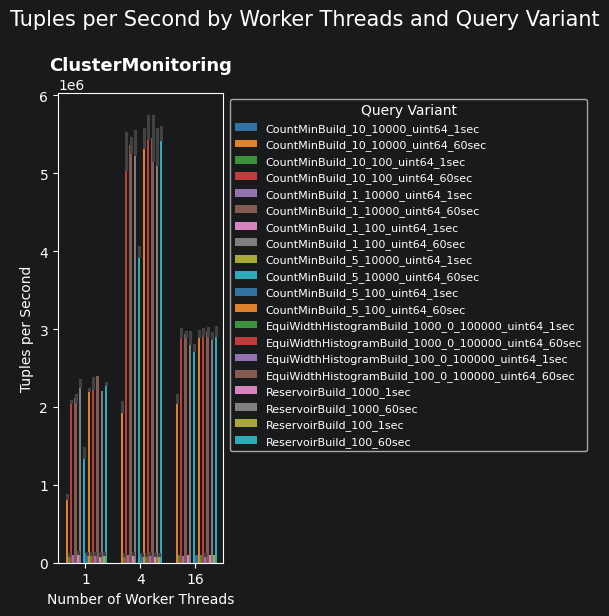

In [2]:
synopsis_types = df["synopsis_type"].unique()
n = len(synopsis_types)

fig, axes = plt.subplots(1, n, figsize=(6 * n, 6), sharey=True)

# Ensure axes is always iterable
if n == 1:
    axes = [axes]

for ax, synopsis in zip(axes, synopsis_types):
    subset = df[df["synopsis_type"] == synopsis]
    hue_order = sorted(subset["query_variant"].dropna().unique())
    palette = sns.color_palette("tab10", len(hue_order))

    sns.barplot(
        data=subset,
        x="numberOfWorkerThreads",
        y="tuplesPerSecond",
        hue="query_variant",
        hue_order=hue_order,
        palette=palette,
        ax=ax,
        errorbar="sd",       # show standard deviation as error bars; use None to disable
    )

    ax.set_title(synopsis, fontsize=13, fontweight="bold")
    ax.set_xlabel("Number of Worker Threads")
    ax.set_ylabel("Tuples per Second" if ax == axes[0] else "")
    ax.legend(title="Query Variant", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

fig.suptitle("Tuples per Second by Worker Threads and Query Variant", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

[numberOfWorkerThreads] Config: dataset=ClusterMonitoring, statistic_type=CountMin, statistic_config=(1, 100, uint64), build_window_size_sec=1, enableLatency=False
  Failure(s): ['crashed (SIGABRT)'] at numberOfWorkerThreads=[np.int64(16)] (1 failed rows)
  Also excluding 8 ok rows at numberOfWorkerThreads=[np.int64(1), np.int64(4), np.int64(16)]

[numberOfWorkerThreads] Config: dataset=ClusterMonitoring, statistic_type=CountMin, statistic_config=(5, 10000, uint64), build_window_size_sec=1, enableLatency=False
  Failure(s): ['oom_killed', 'failed (exit code 11)'] at numberOfWorkerThreads=[np.int64(1), np.int64(4), np.int64(16)] (9 failed rows)
  Also excluding 0 ok rows at numberOfWorkerThreads=[]

[numberOfWorkerThreads] Config: dataset=ClusterMonitoring, statistic_type=CountMin, statistic_config=(10, 10000, uint64), build_window_size_sec=1, enableLatency=False
  Failure(s): ['oom_killed'] at numberOfWorkerThreads=[np.int64(1), np.int64(4), np.int64(16)] (9 failed rows)
  Also excludi

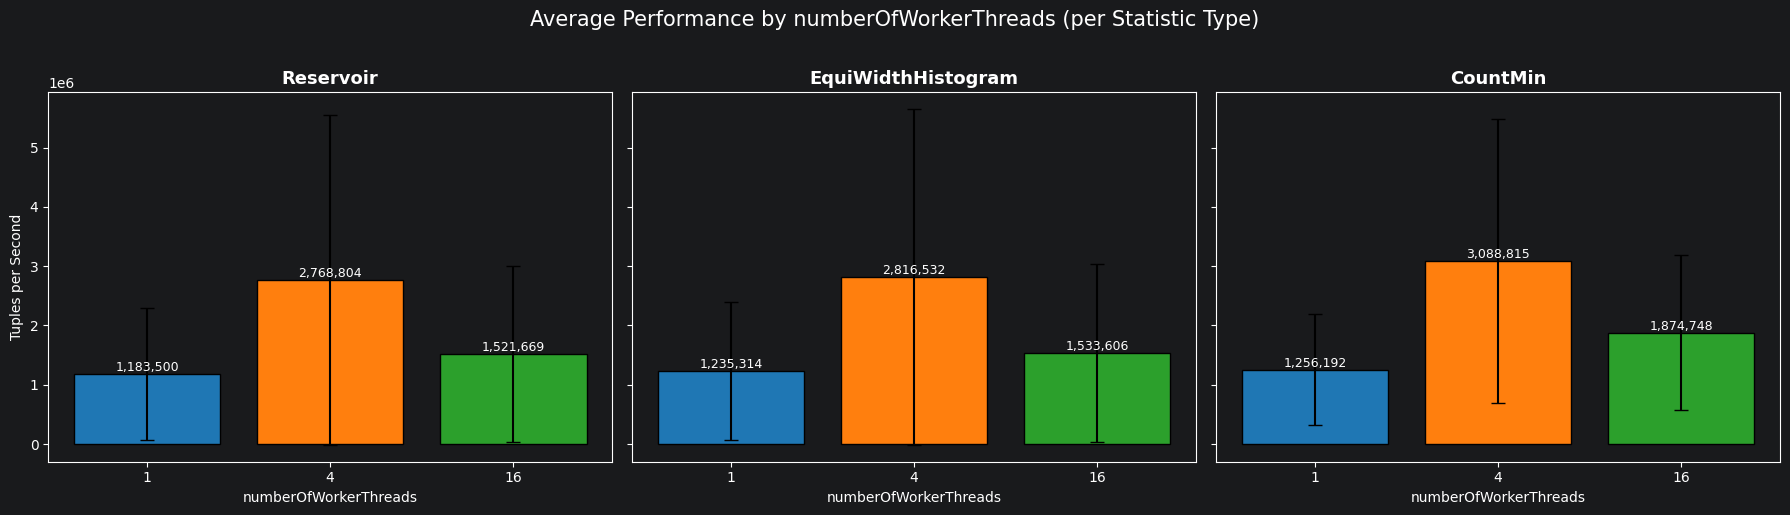

[build_window_size_sec] Config: dataset=ClusterMonitoring, statistic_type=CountMin, statistic_config=(1, 100, uint64), numberOfWorkerThreads=16, enableLatency=False
  Failure(s): ['crashed (SIGABRT)'] at build_window_size_sec=[np.int64(1)] (1 failed rows)
  Also excluding 5 ok rows at build_window_size_sec=[np.int64(1), np.int64(60)]

[build_window_size_sec] Config: dataset=ClusterMonitoring, statistic_type=CountMin, statistic_config=(5, 10000, uint64), numberOfWorkerThreads=1, enableLatency=False
  Failure(s): ['oom_killed'] at build_window_size_sec=[np.int64(1)] (3 failed rows)
  Also excluding 3 ok rows at build_window_size_sec=[np.int64(60)]

[build_window_size_sec] Config: dataset=ClusterMonitoring, statistic_type=CountMin, statistic_config=(5, 10000, uint64), numberOfWorkerThreads=4, enableLatency=False
  Failure(s): ['oom_killed', 'failed (exit code 11)'] at build_window_size_sec=[np.int64(1)] (3 failed rows)
  Also excluding 3 ok rows at build_window_size_sec=[np.int64(60)]

[b

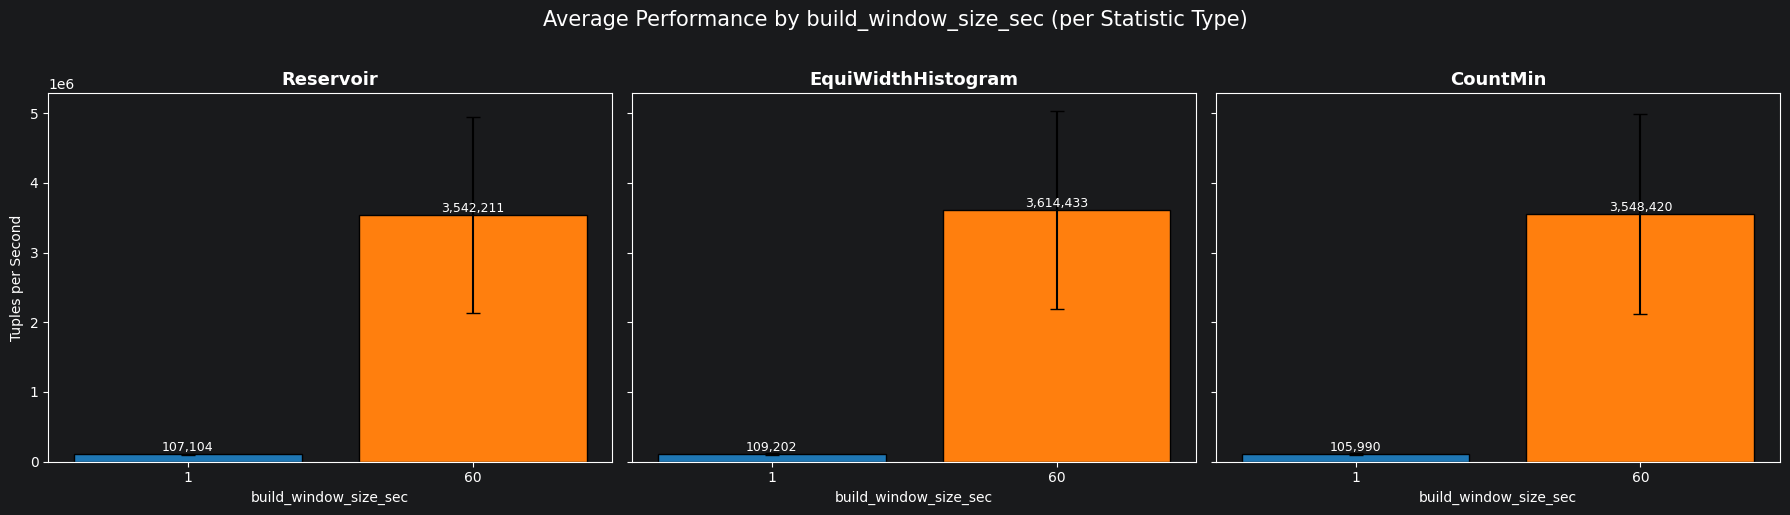

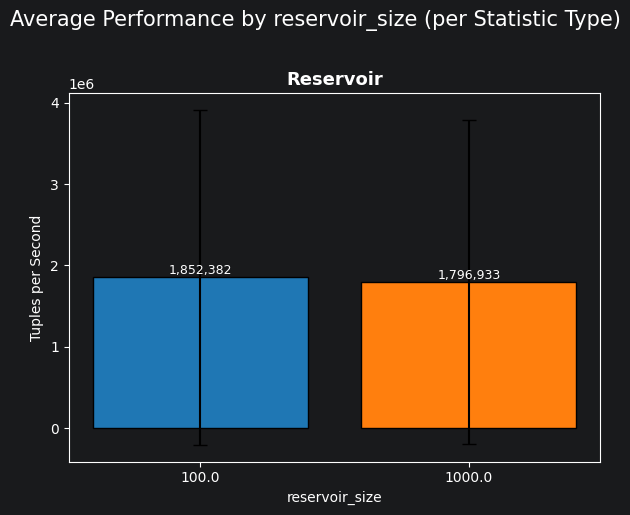

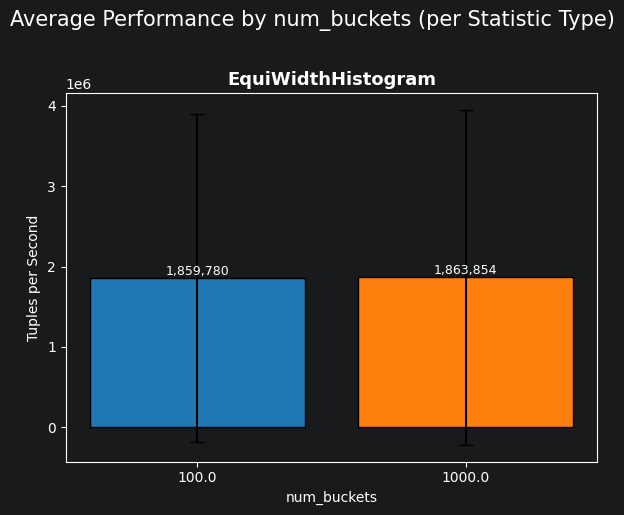

[cm_rows] Config: dataset=ClusterMonitoring, statistic_type=CountMin, statistic_config=(1, 100, uint64), build_window_size_sec=1, numberOfWorkerThreads=16, enableLatency=False
  Failure(s): ['crashed (SIGABRT)'] at cm_rows=[np.float64(1.0)] (1 failed rows)
  Also excluding 2 ok rows at cm_rows=[np.float64(1.0)]

[cm_rows] Config: dataset=ClusterMonitoring, statistic_type=CountMin, statistic_config=(5, 10000, uint64), build_window_size_sec=1, numberOfWorkerThreads=1, enableLatency=False
  Failure(s): ['oom_killed'] at cm_rows=[np.float64(5.0)] (3 failed rows)
  Also excluding 0 ok rows at cm_rows=[]

[cm_rows] Config: dataset=ClusterMonitoring, statistic_type=CountMin, statistic_config=(5, 10000, uint64), build_window_size_sec=1, numberOfWorkerThreads=4, enableLatency=False
  Failure(s): ['oom_killed', 'failed (exit code 11)'] at cm_rows=[np.float64(5.0)] (3 failed rows)
  Also excluding 0 ok rows at cm_rows=[]

[cm_rows] Config: dataset=ClusterMonitoring, statistic_type=CountMin, stati

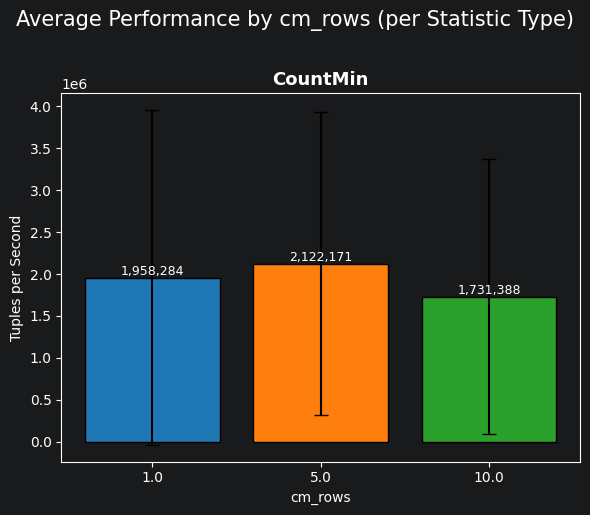

[cm_cols] Config: dataset=ClusterMonitoring, statistic_type=CountMin, statistic_config=(1, 100, uint64), build_window_size_sec=1, numberOfWorkerThreads=16, enableLatency=False
  Failure(s): ['crashed (SIGABRT)'] at cm_cols=[np.float64(100.0)] (1 failed rows)
  Also excluding 2 ok rows at cm_cols=[np.float64(100.0)]

[cm_cols] Config: dataset=ClusterMonitoring, statistic_type=CountMin, statistic_config=(5, 10000, uint64), build_window_size_sec=1, numberOfWorkerThreads=1, enableLatency=False
  Failure(s): ['oom_killed'] at cm_cols=[np.float64(10000.0)] (3 failed rows)
  Also excluding 0 ok rows at cm_cols=[]

[cm_cols] Config: dataset=ClusterMonitoring, statistic_type=CountMin, statistic_config=(5, 10000, uint64), build_window_size_sec=1, numberOfWorkerThreads=4, enableLatency=False
  Failure(s): ['oom_killed', 'failed (exit code 11)'] at cm_cols=[np.float64(10000.0)] (3 failed rows)
  Also excluding 0 ok rows at cm_cols=[]

[cm_cols] Config: dataset=ClusterMonitoring, statistic_type=Cou

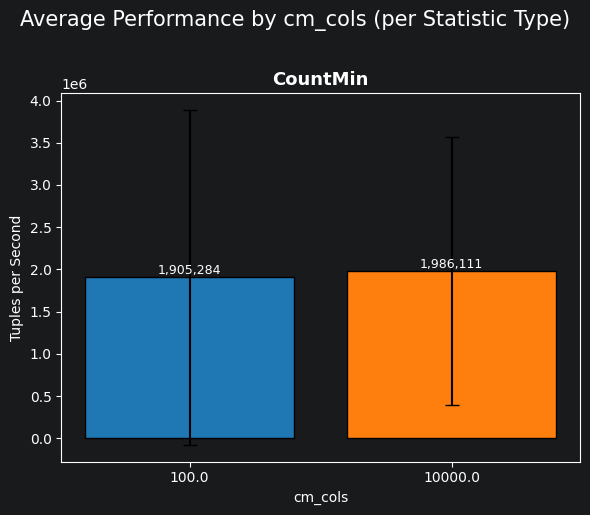

In [3]:
# Columns that together define a unique experiment configuration
CONFIG_COLS = ["dataset", "statistic_type", "statistic_config", "build_window_size_sec", "numberOfWorkerThreads", "enableLatency"]

def filter_failed_configs(df, iterate_param):
    """
    Exclude all runs whose config (ignoring `iterate_param`) has ANY failed run.
    E.g. if iterating over threads: a CountMin config that OOM'd at 16 threads
    causes the 1-thread and 4-thread runs of that same config to be dropped too.
    """
    key_cols = [c for c in CONFIG_COLS if c != iterate_param]
    
    # Find rows with failures and their config keys
    failed_mask = df["issue"] != "ok"
    failed_rows = df.loc[failed_mask]
    failed_keys = failed_rows[key_cols].drop_duplicates()
    
    if failed_keys.empty:
        return df
    
    # Print details about each failed config
    for _, fkey in failed_keys.iterrows():
        # Find the original failure(s) for this config
        mask = (df[key_cols] == fkey).all(axis=1)
        failures = df.loc[mask & failed_mask]
        ok_affected = df.loc[mask & ~failed_mask]
        
        issues = failures["issue"].unique()
        failed_params = failures[iterate_param].unique()
        ok_params = ok_affected[iterate_param].unique()
        
        config_str = ", ".join(f"{c}={fkey[c]}" for c in key_cols)
        print(f"[{iterate_param}] Config: {config_str}")
        print(f"  Failure(s): {list(issues)} at {iterate_param}={list(failed_params)} ({len(failures)} failed rows)")
        print(f"  Also excluding {len(ok_affected)} ok rows at {iterate_param}={list(ok_params)}")
        print()
    
    # Remove all rows matching failed config keys
    merged = df.merge(failed_keys, on=key_cols, how="left", indicator=True)
    clean = merged[merged["_merge"] == "left_only"].drop(columns="_merge")
    
    n_failed = failed_mask.sum()
    n_dropped = len(df) - len(clean)
    n_collateral = n_dropped - n_failed
    print(f"[{iterate_param}] Total: excluded {n_dropped} rows ({n_failed} failed + {n_collateral} ok collateral), {len(clean)} remaining")
    print("---")
    
    return clean

def plot_avg_performance_by(df, param):
    """Bar chart of avg tuples/sec per statistic type, grouped by `param`."""
    df_clean = filter_failed_configs(df, param)
    
    statistic_types = df_clean["statistic_type"].unique()
    n = len(statistic_types)

    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5), sharey=True)
    if n == 1:
        axes = [axes]

    for ax, stat_type in zip(axes, statistic_types):
        subset = df_clean[df_clean["statistic_type"] == stat_type]
        avg = subset.groupby(param)["tuplesPerSecond"].agg(["mean", "std"]).reset_index()
        avg = avg.sort_values(param)

        bars = ax.bar(
            avg[param].astype(str),
            avg["mean"],
            yerr=avg["std"],
            capsize=5,
            color=sns.color_palette("tab10", len(avg)),
            edgecolor="black",
        )

        ax.set_xlabel(param)
        ax.set_ylabel("Tuples per Second" if ax == axes[0] else "")
        ax.set_title(f"{stat_type}", fontsize=13, fontweight="bold")

        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, height, f"{height:,.0f}",
                    ha="center", va="bottom", fontsize=9)

    fig.suptitle(f"Average Performance by {param} (per Statistic Type)", fontsize=15, y=1.02)
    plt.tight_layout()
    plt.show()

# Parse statistic_config into dedicated columns per statistic type
# Reservoir: config is just the reservoir size
mask_res = df["statistic_type"] == "Reservoir"
df.loc[mask_res, "reservoir_size"] = df.loc[mask_res, "statistic_config"].astype(int)

# EquiWidthHistogram: "(num_buckets, min_value, max_value, counter_type)"
mask_hist = df["statistic_type"] == "EquiWidthHistogram"
df.loc[mask_hist, "num_buckets"] = (
    df.loc[mask_hist, "statistic_config"]
    .str.extract(r"\((\d+),")[0].astype(int)
)

# CountMin: "(rows, cols, counter_type)"
mask_cm = df["statistic_type"] == "CountMin"
cm_parts = df.loc[mask_cm, "statistic_config"].str.extract(r"\((\d+),\s*(\d+),")
df.loc[mask_cm, "cm_rows"] = cm_parts[0].astype(int)
df.loc[mask_cm, "cm_cols"] = cm_parts[1].astype(int)

# Common plots for all statistic types
plot_avg_performance_by(df, "numberOfWorkerThreads")
plot_avg_performance_by(df, "build_window_size_sec")

# Per-statistic-type config plots
plot_avg_performance_by(df[mask_res], "reservoir_size")
plot_avg_performance_by(df[mask_hist], "num_buckets")
plot_avg_performance_by(df[mask_cm], "cm_rows")
plot_avg_performance_by(df[mask_cm], "cm_cols")